In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("heart_v2.csv")
df.head()

,age,sex,BP,cholestrol,heart disease
0,70,1,130,322,1
1,67,0,115,564,0
2,57,1,124,261,1
3,64,1,128,263,0
4,74,0,120,269,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   age            270 non-null    int64
 1   sex            270 non-null    int64
 2   BP             270 non-null    int64
 3   cholestrol     270 non-null    int64
 4   heart disease  270 non-null    int64
dtypes: int64(5)
memory usage: 10.7 KB


In [5]:
df.describe()

,age,sex,BP,cholestrol,heart disease
count,270.000000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,131.344444,249.659259,0.444444
std,9.109067,0.468195,17.861608,51.686237,0.497827
min,29.000000,0.000000,94.000000,126.000000,0.000000
25%,48.000000,0.000000,120.000000,213.000000,0.000000
50%,55.000000,1.000000,130.000000,245.000000,0.000000
75%,61.000000,1.000000,140.000000,280.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000


In [11]:
#Distribution in percent
(df['heart disease'].value_counts(normalize=True))*100

heart disease
0    55.555556
1    44.444444
Name: proportion, dtype: float64

In [15]:
X=df.drop('heart disease',axis=1)
y=df['heart disease'].copy()

In [18]:
X.head()

,age,sex,BP,cholestrol
0,70,1,130,322
1,67,0,115,564
2,57,1,124,261
3,64,1,128,263
4,74,0,120,269


In [12]:
## Train-test split
from sklearn.model_selection import train_test_split

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)
X_train.shape,y_train.shape

((216, 4), (216,))

Building the decision tree

In [ ]:

from sklearn.tree import DecisionTreeClassifier

In [24]:
dt=DecisionTreeClassifier(max_depth=3)

In [25]:
dt.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [29]:
from IPython.display import Image
from io import StringIO

from sklearn.tree import export_graphviz
import pydotplus
import graphviz

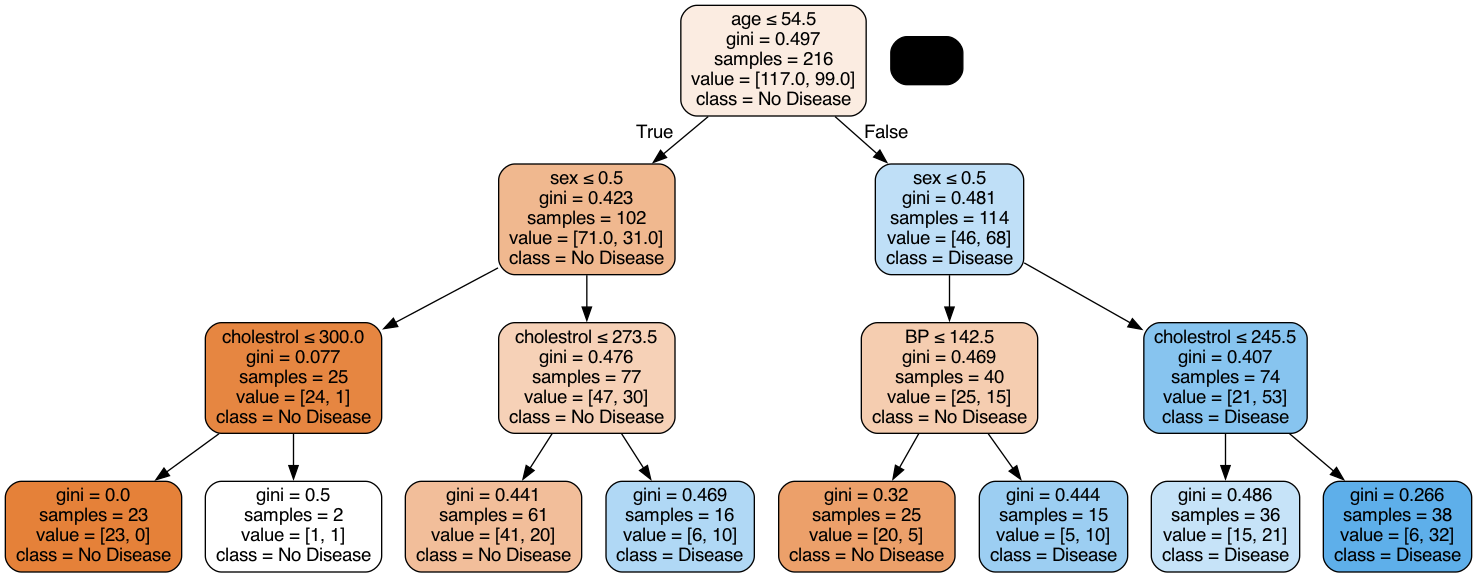

In [37]:
dot_data = StringIO()

export_graphviz(
    dt,
    out_file=dot_data,
    filled=True,
    rounded=True,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

Image(graph.create_png())


##  Understanding the Decision Tree

The Decision Tree is used to predict whether a patient has **Disease** or **No Disease**.

The tree works by asking a series of simple questions about the patient, such as:

- Is the patient's age less than or equal to 54.5?
- Is the patient's sex less than or equal to 0.5?
- Is the cholesterol level less than or equal to 300?
- Is the blood pressure less than or equal to 142.5?

Based on the answers, the patient moves through the tree until reaching a final prediction.

### How to Read the Tree

Each box in the tree contains the following information:

**1. Decision Rule**

Example:

`age <= 54.5`

This means the tree is checking whether the patient's age is less than or equal to 54.5.

- If **True**, move to the left.
- If **False**, move to the right.

**2. Gini**

Gini measures how mixed the classes are in that node.

- Lower Gini → the node is more pure.
- Higher Gini → the node contains a mixture of classes.
- Gini = 0 → the node is completely pure.

For example:

`gini = 0.0`

means all patients in that node belong to the same class.

**3. Samples**

`Samples` shows the number of patients/records present in that node.

For example:

`samples = 38`

means 38 patients reached that node.

**4. Value**

`Value` shows how many patients belong to each class.

For example:

`value = [6, 32]`

means:

- 6 patients → No Disease
- 32 patients → Disease

The total is 38, which matches the number of samples.

**5. Class**

`Class` is the prediction made by the tree at that node.

The tree selects the class with the higher number of samples.

For example:

`value = [6, 32]`

Since 32 patients have Disease and only 6 have No Disease, the predicted class is:

`Disease`

### Example of Following the Tree

Suppose a patient has:

- Age = 60
- Sex = 1
- Cholesterol = 250

The tree follows these steps:

1. `Age <= 54.5` → False
2. Move to the right.
3. `Sex <= 0.5` → False
4. Move to the right.
5. `Cholesterol <= 245.5` → False
6. Move to the right.
7. The final node has `value = [6, 32]`.
8. Since most patients belong to the Disease class, the prediction is **Disease**.

### Key Takeaway

A Decision Tree makes a prediction by asking a sequence of simple questions and following the appropriate path.

**Root Node → Decision Rules → Branches → Leaf Node → Final Prediction**

The tree automatically learns the important features and splitting values from the training data.

In [38]:
## Evaluating the model performance in test set
y_train_pred=dt.predict(X_train)
y_test_pred=dt.predict(X_test)

In [39]:
from sklearn.metrics import confusion_matrix,accuracy_score

In [40]:
print(accuracy_score(y_train,y_train_pred))
confusion_matrix(y_train,y_train_pred)

0.7314814814814815


array([[85, 32],
       [26, 73]])

In [42]:
print(accuracy_score(y_test,y_test_pred))
confusion_matrix(y_test,y_test_pred)

0.6296296296296297


array([[22, 11],
       [ 9, 12]])

## Model Evaluation: Decision Tree for Disease Prediction

`0 = No Disease`, `1 = Disease`

### 1. What are we actually trying to find out?

Suppose you built a Decision Tree to answer:

> "Given a patient's age, sex, cholesterol, BP, etc., can my model predict whether this patient has a disease?"

There are two different questions:

- **Question 1:** Did the model learn from the patients it saw? → **Training Performance**
- **Question 2:** Can the model correctly predict patients it has never seen before? → **Test Performance**

The second question is much more important for real-world usage.


```
Training Data → Model learns → Training Performance
Unseen Test Data → Model predicts → Test Performance
```

### 2. Training Accuracy = 73.15%

There are 216 training patients.

**Training Confusion Matrix:**

|                | Predicted: No Disease | Predicted: Disease |
|----------------|:---------------------:|:-------------------:|
| **Actual: No Disease** | 85 | 32 |
| **Actual: Disease**    | 26 | 73 |

Correct predictions: `85 + 73 = 158`
Total: `216`

$$158 / 216 = 73.15\%$$

### 3. But is 73.15% enough?

Not yet — these are patients the model already saw during training. The more important question is how it performs on **completely unseen** patients.

### 4. Test Accuracy = 62.96%

There are 54 test patients.

**Test Confusion Matrix:**

|                | Predicted: No Disease | Predicted: Disease |
|----------------|:---------------------:|:-------------------:|
| **Actual: No Disease** | 22 | 11 |
| **Actual: Disease**    | 9  | 12 |

### 5–8. Reading each cell

| Value | Actual | Predicted | Meaning | Term |
|-------|--------|-----------|---------|------|
| 22 | No Disease | No Disease | Correct | **True Negative** |
| 11 | No Disease | Disease | Wrong — unnecessary follow-up testing | **False Positive** |
| 9  | Disease | No Disease | Wrong — a real case was missed | **False Negative** |
| 12 | Disease | Disease | Correct | **True Positive** |

### 9. Putting it together

- Correct: `22 + 12 = 34`
- Incorrect: `11 + 9 = 20`

$$34 / 54 = 62.96\%$$

### 10. The most important part — the generalization gap

| Metric | Value |
|--------|:-----:|
| Training Accuracy | 73.15% |
| Test Accuracy | 62.96% |
| **Gap** | **~10.19 pts** |

This tells us the model performs noticeably better on data it learned from than on unseen data — a **generalization gap**. This *can* indicate overfitting, or simply weak generalization; more analysis is needed before concluding it's definite overfitting.

### 11. Why should you care?

"My Decision Tree has 73% accuracy" sounds fine — until someone asks how it does on new patients, and the answer is 62.96%. **Never report only training accuracy.**

### 12. Comparing to a naive baseline

In the test set:
- Actual No Disease: `22 + 11 = 33`
- Actual Disease: `9 + 12 = 21`

A trivial model that **always predicts "No Disease"** would get:

$$33 / 54 = 61.11\%$$

Your model gets **62.96%** — only about **1.85 percentage points** above this majority-class baseline. This means test accuracy alone doesn't demonstrate strong predictive performance here.

### 13. Recall — did we catch the disease cases?

$$\text{Recall} = \frac{TP}{TP + FN} = \frac{12}{12+9} = 57.14\%$$

The model identified about 57% of actual disease cases, missing `9 / 21 ≈ 42.86%` of them.

### 14. Precision — how trustworthy are positive predictions?

Model predicted "Disease" for `11 + 12 = 23` patients; only 12 were correct.

$$\text{Precision} = \frac{12}{23} = 52.17\%$$

### 15. Summary

> The Decision Tree achieved 73.15% accuracy on training data but only 62.96% on unseen test data. The test confusion matrix shows 22 true negatives, 12 true positives, 11 false positives, and 9 false negatives. The model's disease recall is approximately 57%, meaning it identified 12 of the 21 actual disease cases. Test accuracy is also only slightly above the majority-class baseline for this split, so further model improvement and evaluation would be appropriate.

## Why Isn't the Model Performing Well? — Introducing Hyperparameters

You can see that the model we have now is **not performing well on the test set**. This is because we built our model using default parameters except for `max_depth`, and didn't tune any other hyperparameters.

**Hyperparameter tuning can improve the performance of decision trees to a great extent.** So in the upcoming sessions, we'll go ahead and exploit these parameters to improve the model and get better prediction results.

### What are Hyperparameters?

**Hyperparameters** are the parameters we pass to the learning algorithm to control how the model is trained. They are choices the algorithm designer makes to *"tune"* the behaviour of the learning algorithm. Since the choice of hyperparameters has a big impact on the final model, tuning them well really matters.

In short:

> Anything passed to the algorithm **before** training begins is a hyperparameter. These are set by the user — **not** learned by the algorithm on its own during training.

### Example: `max_depth`

One of the hyperparameters you provided was **`max_depth`**, which determines how many levels of nodes exist from the root to a leaf.

- The algorithm **cannot** decide this value on its own.
- It has to be **provided by the user**.
- That's exactly what makes it a **hyperparameter** (as opposed to a *parameter*, which the model learns from the data during training).

| Measure                  | Best / Pure | Worst / Most Mixed | Good direction |
| ------------------------ | ----------: | -----------------: | -------------- |
| **Classification Error** |       **0** |                0.5 | Closer to 0 ✅  |
| **Gini**                 |       **0** |                0.5 | Closer to 0 ✅  |
| **Entropy**              |       **0** |                1.0 | Closer to 0 ✅  |


              START
                |
          Gini = 0.48
                |
       Try different features
          /           \
        Sex       Cholesterol
         |              |
      Gini .42       Gini .30
         |              |
     Reduction       Reduction
       .06              .18
         |              |
         └──────┬───────┘
                ↓
        Choose larger reduction
                ↓
           CHOLESTEROL

Gini tells us how impure the node is.
Gini reduction tells us how good the split is.
Feature importance tells us which features contributed most to impurity reduction across the trained tree

In [43]:
## create a helper function to evaluate the model performance and create the graph for DT


In [82]:
def get_dt_graph(dt_classifier):
    dot_data = StringIO()

    export_graphviz(
        dt_classifier,
        out_file=dot_data,
        filled=True,
        rounded=True,
        feature_names=X.columns,
        class_names=['No Disease', 'Disease'],
        special_characters=True
    )
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

    return graph


In [83]:
def evaluate_model(dt_classifier):
    y_train_pred=dt_classifier.predict(X_train)
    y_test_pred=dt_classifier.predict(X_test)
    print("Train set performace")
    print(accuracy_score(y_train,y_train_pred))
    confusion_matrix(y_train,y_train_pred)

    print("-"*20)

    print("test set performance")
    print(accuracy_score(y_test,y_test_pred))
    confusion_matrix(y_test,y_test_pred)

In [84]:
evaluate_model(dt)

Train set performace
0.7314814814814815
--------------------
test set performance
0.6296296296296297


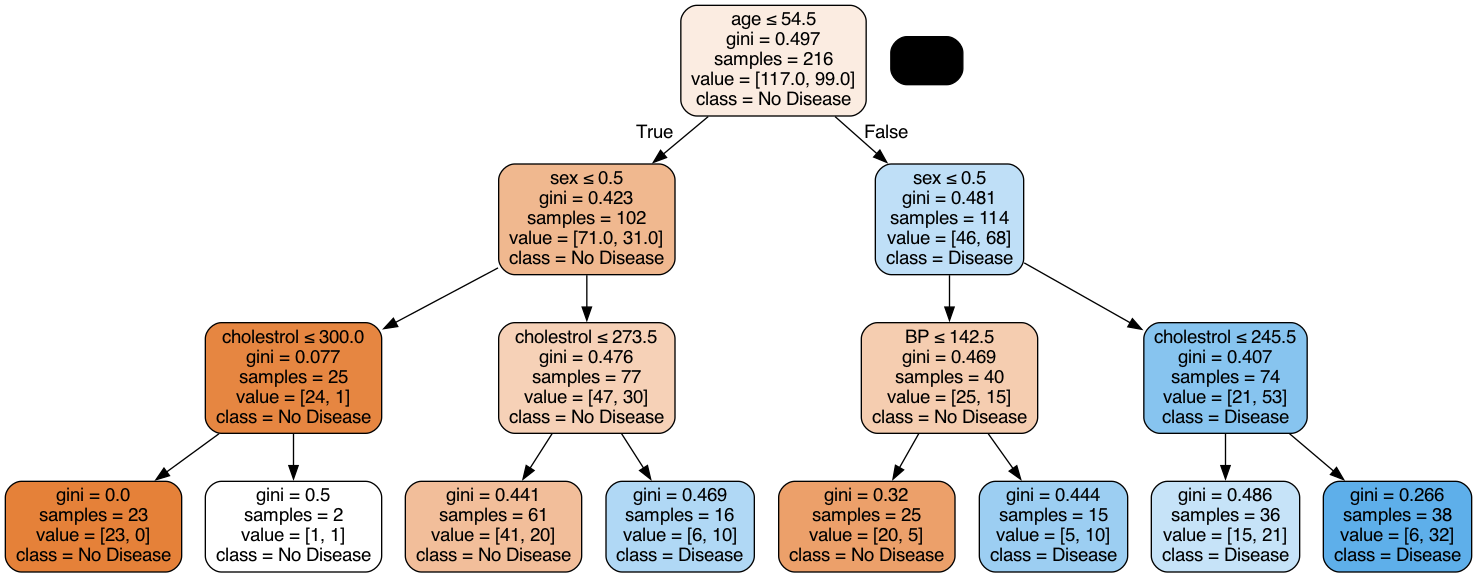

In [85]:
gph=get_dt_graph(dt)
Image(gph.create_png())

In [86]:
## Decision tre without any hyperparameter setting


In [87]:
dt_default=DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

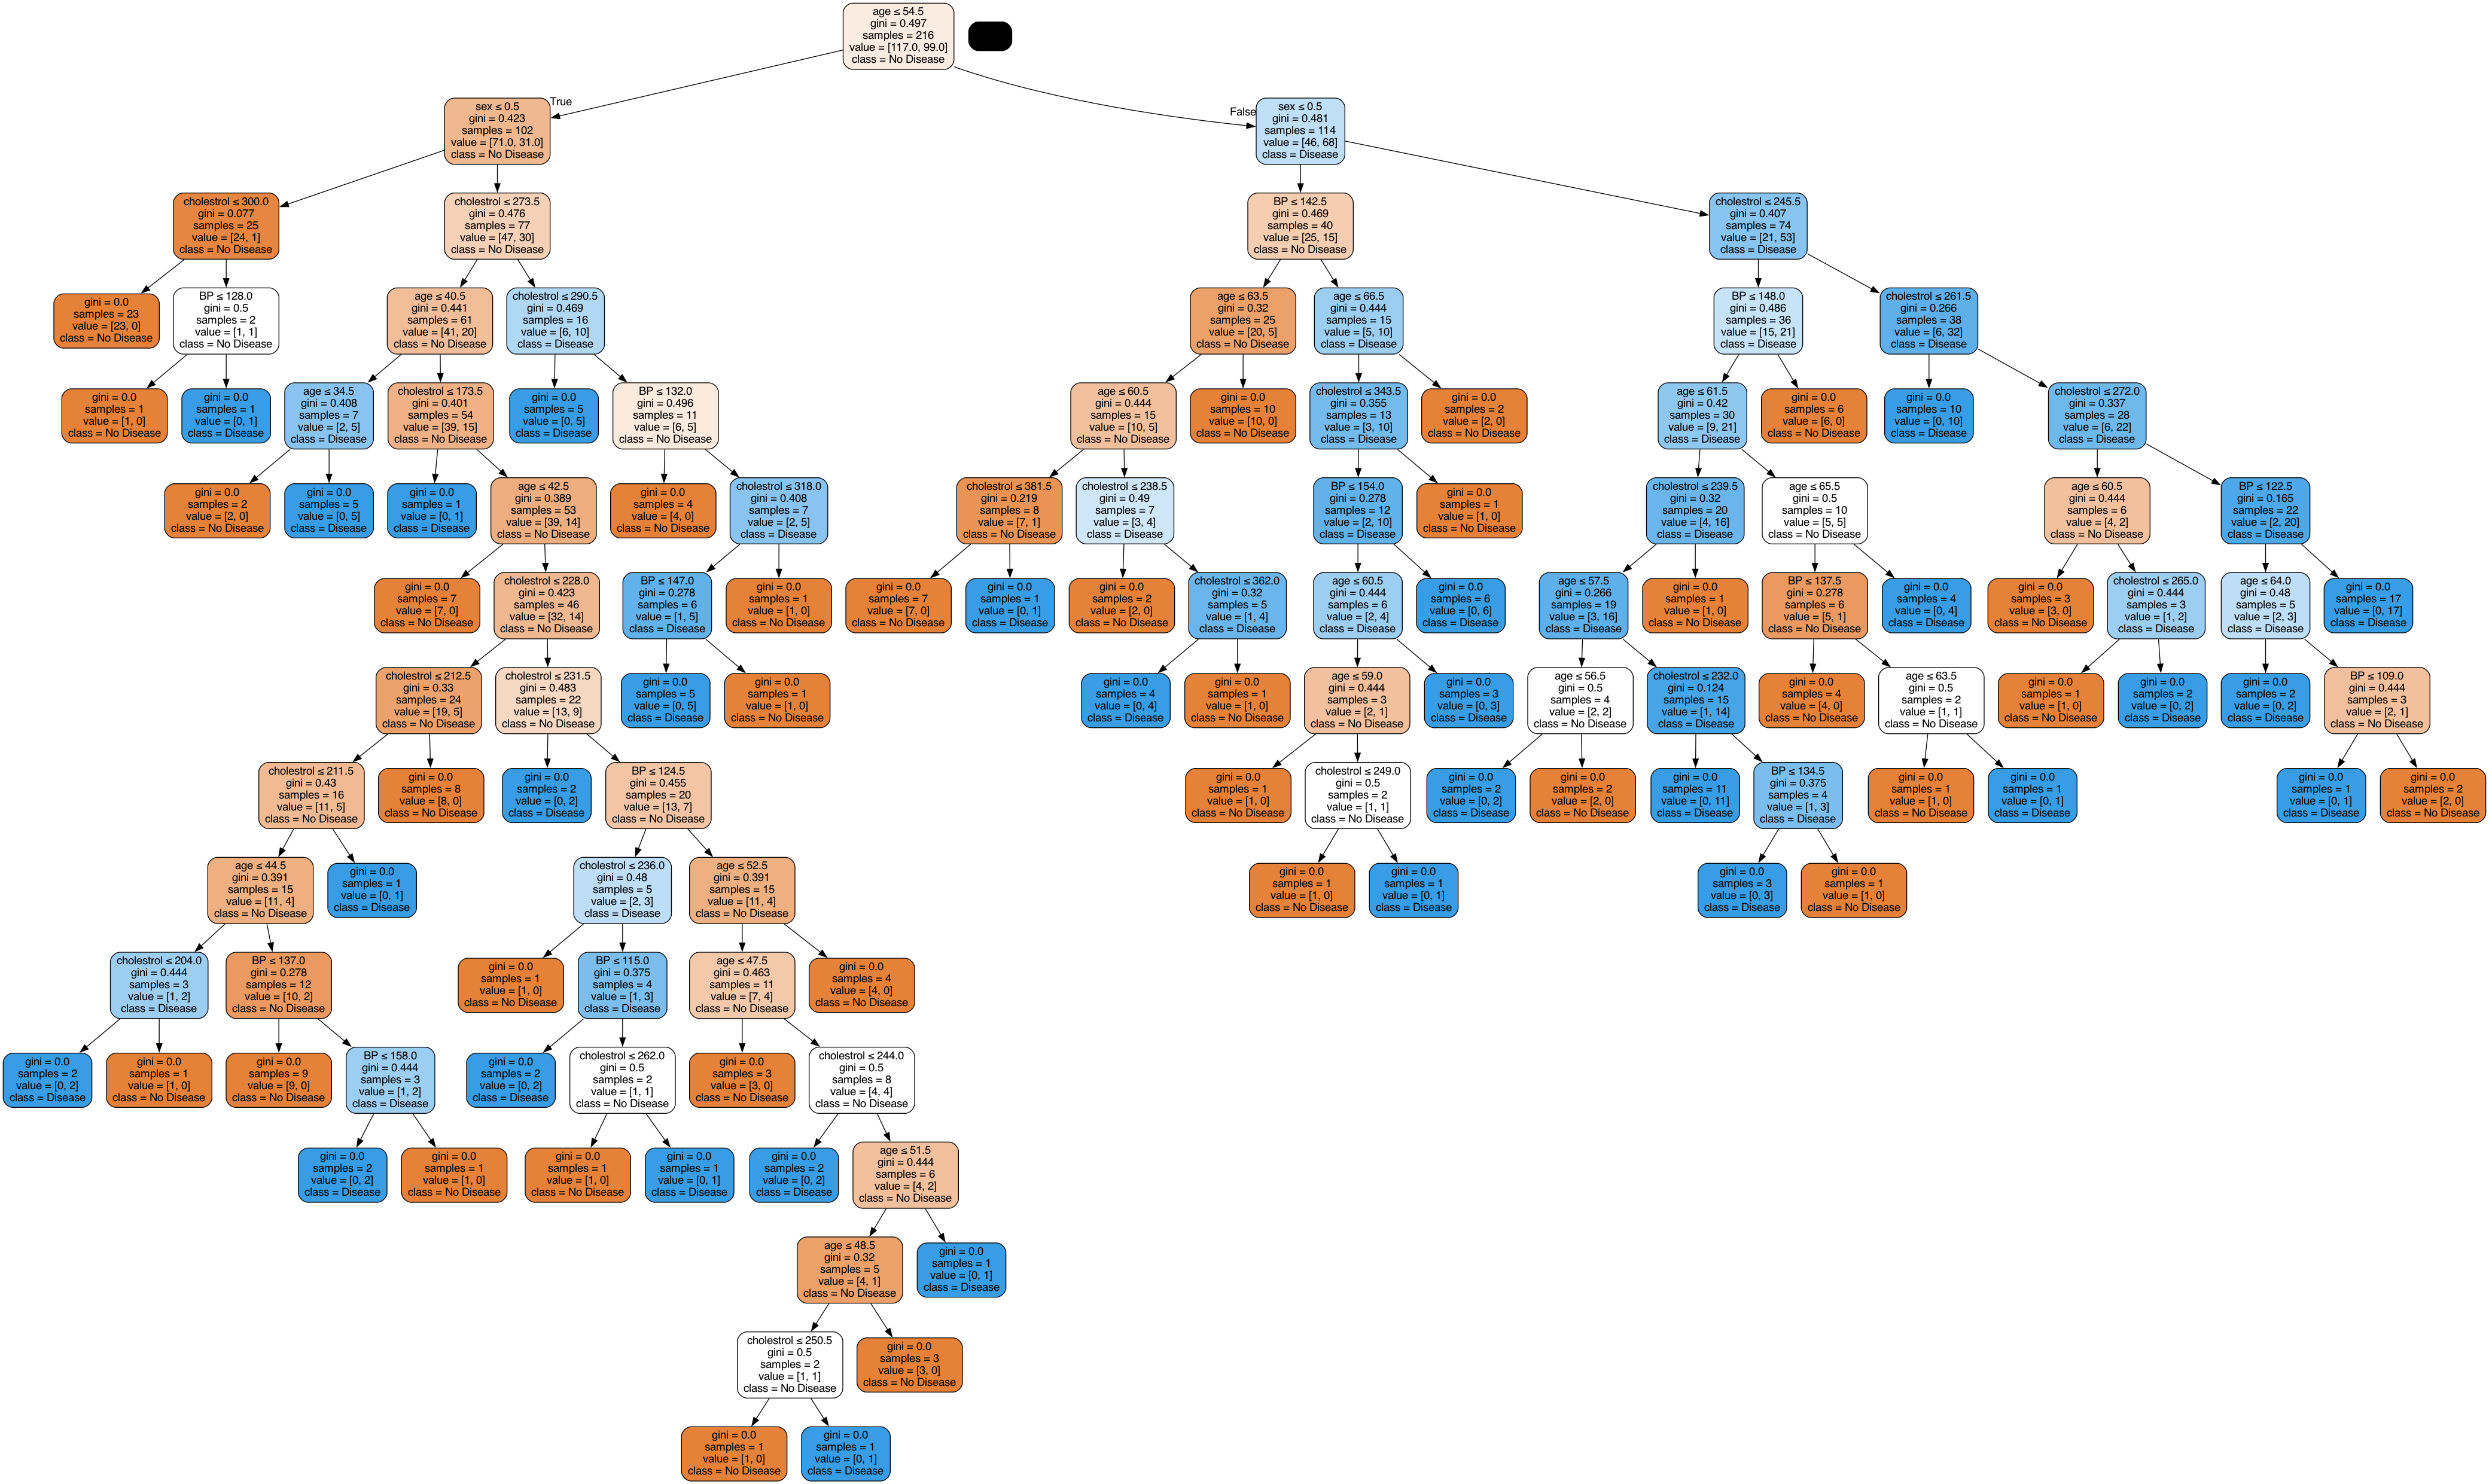

In [88]:
gph=get_dt_graph(dt_default)
Image(gph.create_png())

In [89]:
evaluate_model(dt_default)

Train set performace
1.0
--------------------
test set performance
0.5925925925925926


In [90]:
#Controlling the depth of the tree 

In [91]:
dt_depth=DecisionTreeClassifier(max_depth=2,random_state=42)
dt_depth.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

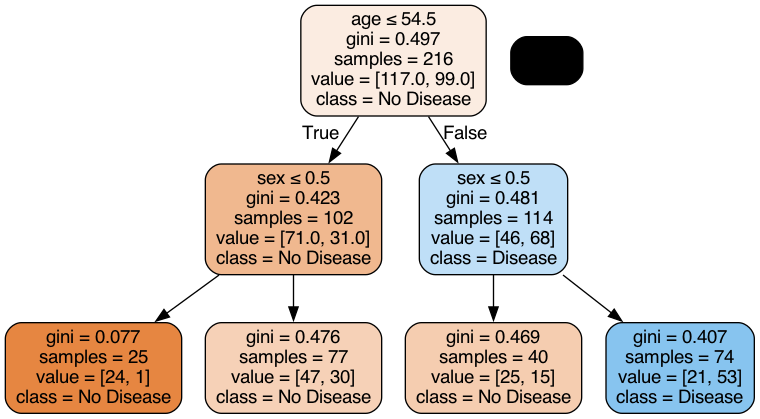

In [92]:
gph=get_dt_graph(dt_depth)
Image(gph.create_png())

In [93]:
evaluate_model(dt_depth)

Train set performace
0.6898148148148148
--------------------
test set performance
0.6666666666666666


In [94]:
##Specify the minimum samples before split 


In [95]:
dt_min_split=DecisionTreeClassifier(min_samples_split=40,random_state=42)
dt_min_split.fit(X_train,y_train)

,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

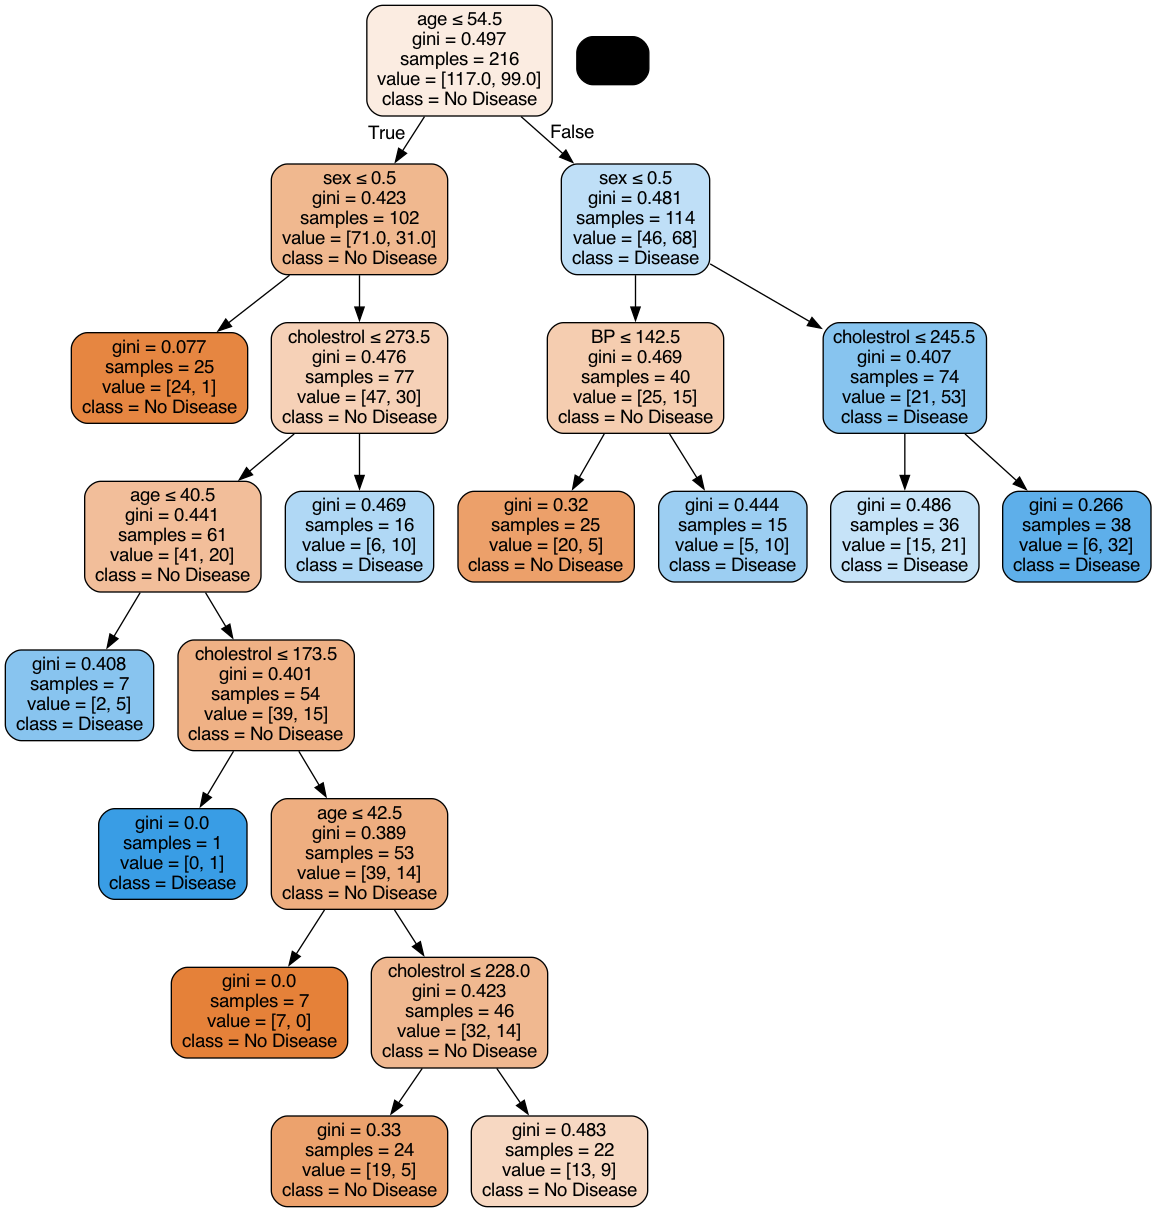

In [96]:
gph=get_dt_graph(dt_min_split)
Image(gph.create_png())

In [97]:
evaluate_model(dt_min_split)

Train set performace
0.75
--------------------
test set performance
0.6111111111111112


In [98]:
## specify the minimum sample in leaf node 

In [99]:
dt_min_leaf=DecisionTreeClassifier(min_samples_leaf=20,random_state=42)
dt_min_leaf.fit(X_train,y_train)

,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

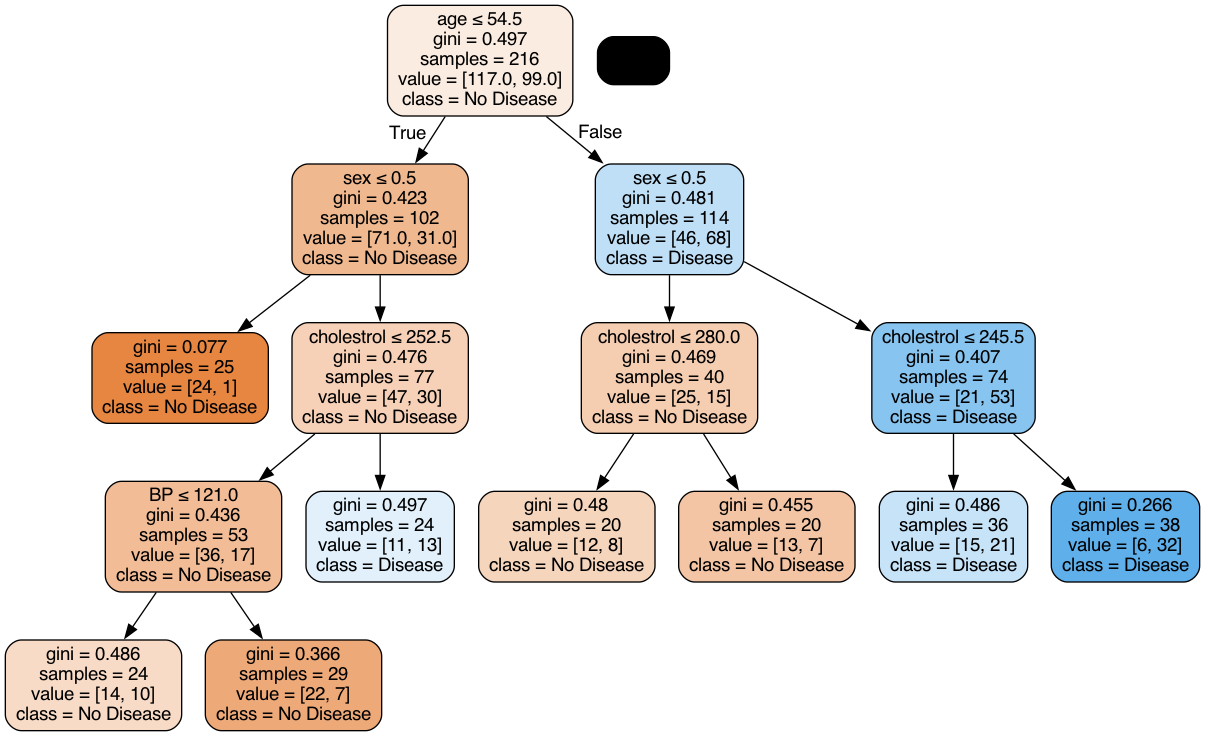

In [100]:
gph=get_dt_graph(dt_min_leaf)
Image(gph.create_png())

In [101]:
evaluate_model(dt_min_leaf)

Train set performace
0.6990740740740741
--------------------
test set performance
0.6111111111111112


In [102]:
##Using entroy instead of Gini


In [106]:
dt_min_leaf_entropy=DecisionTreeClassifier(min_samples_leaf=20,random_state=42,criterion="entropy")
dt_min_leaf_entropy.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamp

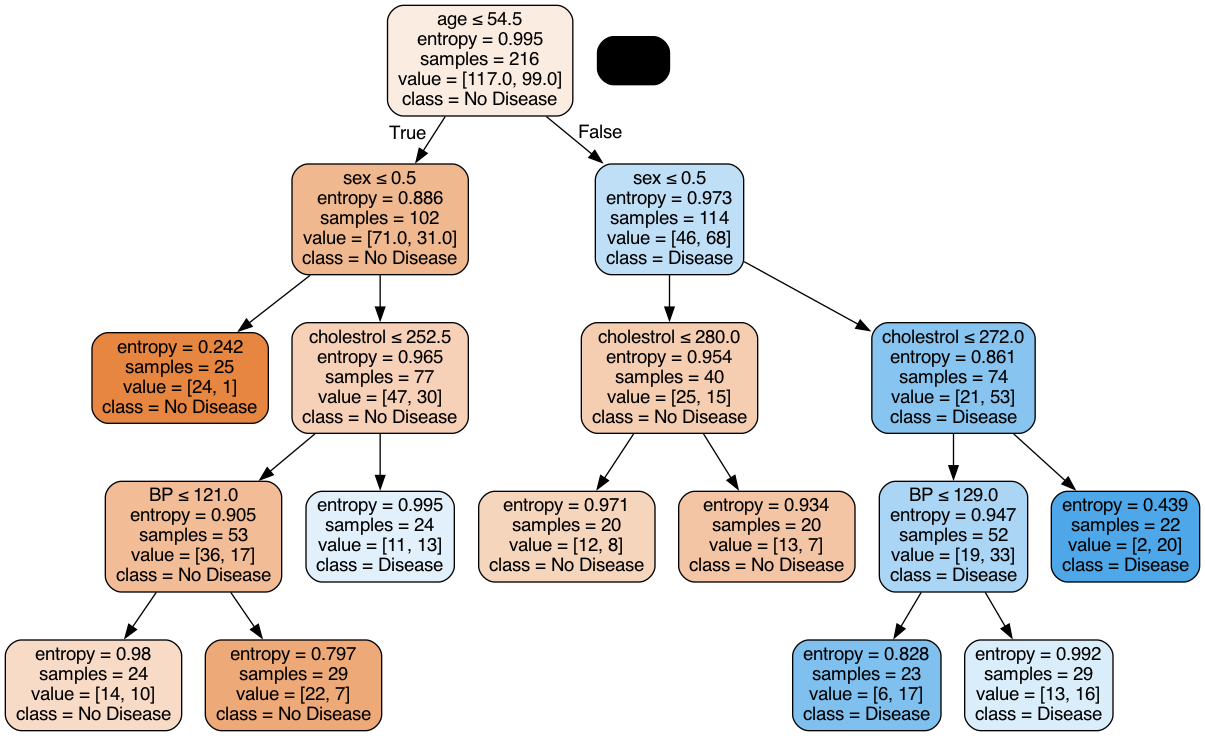

In [107]:
gph=get_dt_graph(dt_min_leaf_entropy)
Image(gph.create_png())

In [108]:
evaluate_model(dt_min_leaf_entropy)

Train set performace
0.6990740740740741
--------------------
test set performance
0.6111111111111112


In [109]:
##Hyper-parameter tuning using gridsearch cv

In [117]:
dt=DecisionTreeClassifier(random_state=42)


In [118]:
from sklearn.model_selection import GridSearchCV

In [207]:
params = {
    'max_depth': [3, 4, 5, 7, 10],
    'min_samples_leaf': [15, 20, 22, 25, 30],
    'criterion': ['gini', 'entropy']
}

In [208]:
grid_search=GridSearchCV(estimator=dt,
             param_grid=params,
             cv=4,
             n_jobs=-1,verbose=1,
             scoring="accuracy")

In [209]:
%%time
grid_search.fit(X_train,y_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits
CPU times: user 116 ms, sys: 21.6 ms, total: 138 ms
Wall time: 275 ms


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [15, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plo

In [210]:
cv_df=pd.DataFrame(grid_search.cv_results_)
cv_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.049258,0.030514,0.004633,0.001083,gini,3,15,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.574074,0.62963,0.685185,0.722222,0.652778,0.056131,31
1,0.018906,0.009581,0.001872,0.000611,gini,3,20,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.648148,0.62963,0.703704,0.722222,0.675926,0.038177,6
2,0.004412,0.001475,0.001815,0.000983,gini,3,22,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.648148,0.62963,0.703704,0.722222,0.675926,0.038177,6
3,0.002871,0.000947,0.001667,0.000561,gini,3,25,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.648148,0.62963,0.703704,0.722222,0.675926,0.038177,6
4,0.001682,0.000803,0.000922,0.000402,gini,3,30,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.648148,0.62963,0.537037,0.722222,0.634259,0.065962,41


In [211]:
cv_df.nlargest(5,'mean_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
28,0.000818,0.000134,0.000634,0.000042,entropy,3,25,"{'criterion': 'entropy', 'max_depth': 3, 'min_...",0.648148,0.648148,0.703704,0.722222,0.680556,0.033062,1
33,0.000814,0.000149,0.001064,0.000754,entropy,4,25,"{'criterion': 'entropy', 'max_depth': 4, 'min_...",0.648148,0.648148,0.703704,0.722222,0.680556,0.033062,1
38,0.001104,0.000467,0.000722,0.000159,entropy,5,25,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.648148,0.648148,0.703704,0.722222,0.680556,0.033062,1
43,0.000959,0.000389,0.001308,0.001149,entropy,7,25,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.648148,0.648148,0.703704,0.722222,0.680556,0.033062,1
48,0.001425,0.000494,0.000810,0.000147,entropy,10,25,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.648148,0.648148,0.703704,0.722222,0.680556,0.033062,1


In [212]:
grid_search.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [213]:
grid_search.best_score_

np.float64(0.6805555555555556)

In [214]:
dt_best=grid_search.best_estimator_


In [215]:
evaluate_model(dt_best)

Train set performace
0.6898148148148148
--------------------
test set performance
0.6666666666666666


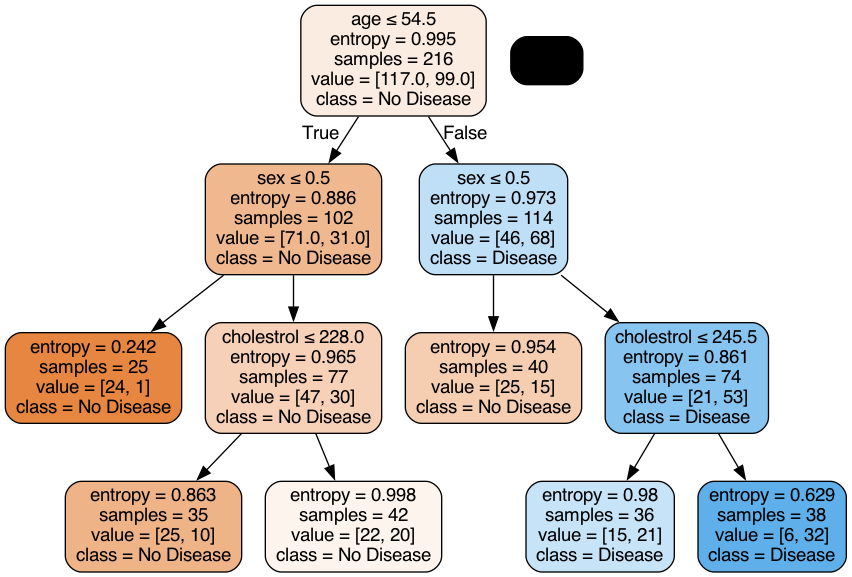

In [216]:
gph=get_dt_graph(dt_best)
Image(gph.create_png())